The code in this notebook processes two data sets (df_seatttle and df_detroit) and extracts the precipitation measured over 5 years from both sets to create a new cleaned data set (Clean_Seattle_Detroit_Weather). Once completed, the cleaned data set is undergoes data anaylsis where different statistical tests and graphs are created to determine if it rains more in Seattle or Detroit.

In [1]:
#importing libraries that allow data sets to be imported, processed, and create visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
#libraries imported and setup seaborn library style as whitegrid

The data sets are pulled from two weather stations listed on the NOAA government website(National Centers for Environmental Information). One in Seattle, WA, USA and the other in Detroit, MI, USA. The weather stations measured a variety of weather conditions involving precipitation and snowfall. 

In [2]:
#import Weather station datasets for Seattle and Detroit
df_seattle = pd.read_csv(
    'https://raw.githubusercontent.com/Ninofo/Weather/refs/heads/main/seattle_rain.csv'
)
df_detroit = pd.read_csv(
    'https://raw.githubusercontent.com/Ninofo/Weather/refs/heads/main/Detroit_rain.csv'
)
#imported datasets from Github repository 

In [3]:
#Exploring datasets for both seattle and Detroit weather stations. Inspecting what data is included in each dataset.
type(df_seattle)

pandas.DataFrame

In [4]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [5]:
df_detroit.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00094847,"DETROIT METRO AIRPORT, MI US",2018-01-01,0.00,0.0,5.9
1,USW00094847,"DETROIT METRO AIRPORT, MI US",2018-01-02,0.00,0.0,5.9
2,USW00094847,"DETROIT METRO AIRPORT, MI US",2018-01-03,0.01,0.5,5.9
3,USW00094847,"DETROIT METRO AIRPORT, MI US",2018-01-04,0.00,0.0,5.9
4,USW00094847,"DETROIT METRO AIRPORT, MI US",2018-01-05,0.00,0.0,5.9


In [6]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='str')

In [7]:
df_detroit.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

In [8]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [9]:
df_detroit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 173.1 KB


In [10]:
print(df_seattle.shape)

(1658, 10)


In [11]:
print(df_detroit.shape)

(1826, 6)


In [12]:
df_detroit['STATION']

0       USW00094847
1       USW00094847
2       USW00094847
3       USW00094847
4       USW00094847
           ...     
1821    USW00094847
1822    USW00094847
1823    USW00094847
1824    USW00094847
1825    USW00094847
Name: STATION, Length: 1826, dtype: str

In [13]:
df_detroit['STATION'].unique()

<ArrowStringArray>
['USW00094847']
Length: 1, dtype: str

In [14]:
df_seattle['STATION'].unique()
#

<ArrowStringArray>
['US1WAKG0225']
Length: 1, dtype: str

In [15]:
df_detroit['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1821    2022-12-27
1822    2022-12-28
1823    2022-12-29
1824    2022-12-30
1825    2022-12-31
Name: DATE, Length: 1826, dtype: str

Discovered Seattle dataFrame has more columns than Detroit dataFrame, Detroit dataFrame has more rows, both datasets include only one weather station, and both have common column of 'DATE' that is a string datatype

In [16]:
#converting 'DATE' data type from string to dateTime datatype in both dataFrames
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])

C:\Users\Owner\AppData\Local\Temp\ipykernel_1572\4149020625.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


In [17]:
df_detroit['DATE']=pd.to_datetime(df_detroit['DATE'])

In [18]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

In [19]:
df_detroit['DATE'].agg(['min','max'])
#converted 'Date' column values from string to dateTime datatype and confirmed only intended dates were included in the date range

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

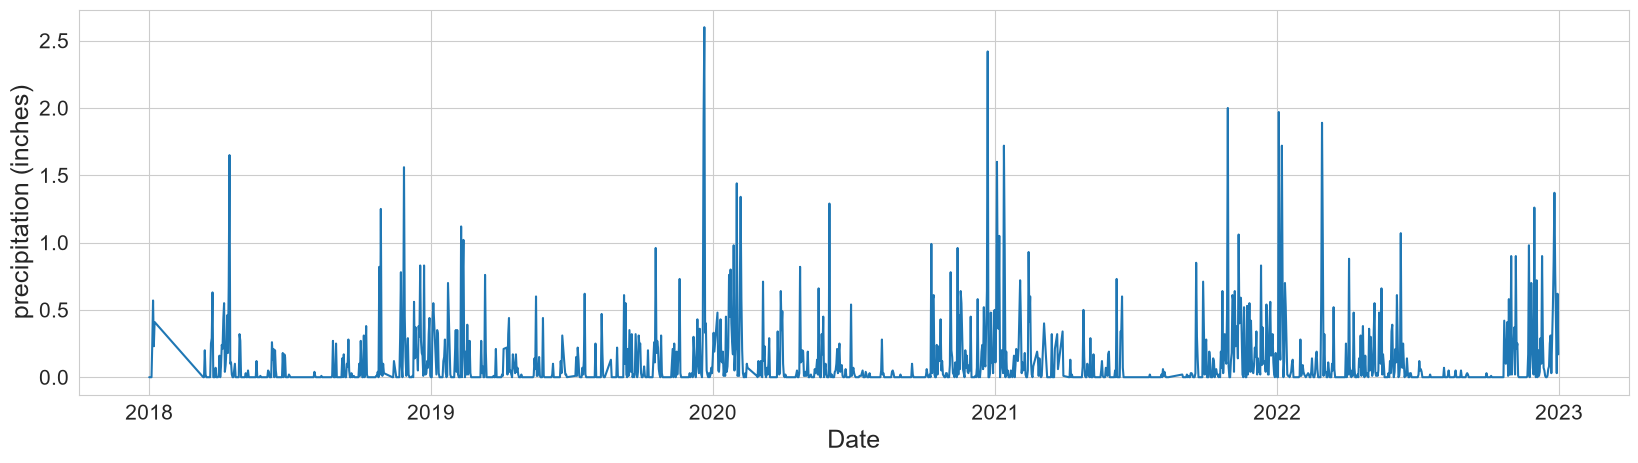

In [20]:
#visualize seattle and Detroit dataFrames separately to quickly scan for any gaps in data
plt.figure(figsize=(20,5))
sns.lineplot(data=df_seattle, x='DATE', y='PRCP')
plt.xlabel("Date", fontsize=18)
plt.ylabel("precipitation (inches)", fontsize = 18)
plt.tick_params(labelsize=15)
plt.show()

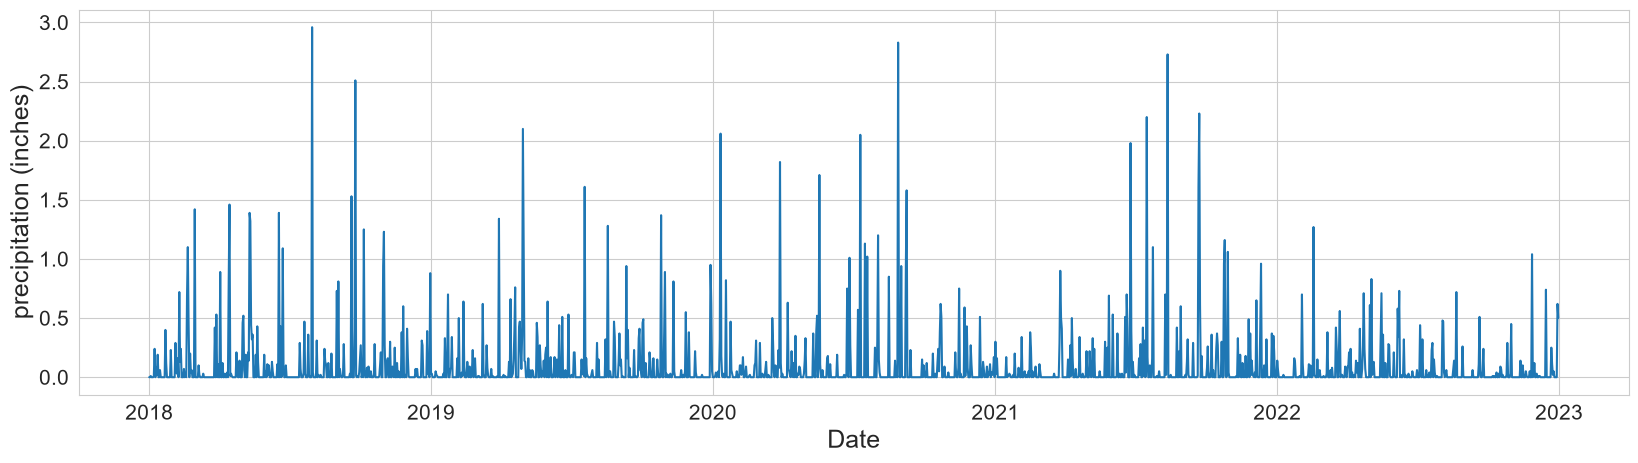

In [21]:
plt.figure(figsize=(20,5))
sns.lineplot(data=df_detroit, x='DATE', y='PRCP')
plt.xlabel("Date", fontsize=18)
plt.ylabel("precipitation (inches)", fontsize = 18)
plt.tick_params(labelsize=15)
plt.show()
#Seattle dataFrame appears to be missing data in the beginning of 2018 while Detroit DataFrame was larger but did not appear to have any missing data

In [22]:
#join 'DATE' and 'PRCP' subsections from Detroit and Seattle DataFrames together to create a new dataFrame
df = df_detroit[['DATE', 'PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [23]:
df.head()
#confirmed merge of subsections into a new dataFrame 

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.01,0.00
3,2018-01-04,0.00,0.00
4,2018-01-05,0.00,0.25


In [24]:
#Convert dataFrame from wide to tidy 
df=pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [25]:
df.head()
#confirmed conversion of wide dataFrame to tidy dataFrame. Resulted in precipitation values from each dataFrame being differentiated by suffix '_x' and '_y'

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.01
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,0.00


In [26]:
#rename city values to more clearly show which city's weather station collected the value
df.loc[df['city'] == 'PRCP_x', 'city'] = 'DTW'

In [27]:
df.loc[df['city']=='PRCP_y', 'city']='SEA'

In [28]:
df.head()

,DATE,city,precipitation
0,2018-01-01,DTW,0.00
1,2018-01-02,DTW,0.00
2,2018-01-03,DTW,0.01
3,2018-01-04,DTW,0.00
4,2018-01-05,DTW,0.00


In [29]:
df.tail()
#confirmed value representation changed. DTW = Detroit Airport and SEA = Seattle Airport

,DATE,city,precipitation
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62
3651,2022-12-31,SEA,0.17


In [30]:
#make DATE column Header lowercase
df = df.rename(columns = {'DATE': 'date'})

In [31]:
df.head()
#confirmed Date column Header became lowercase

,date,city,precipitation
0,2018-01-01,DTW,0.00
1,2018-01-02,DTW,0.00
2,2018-01-03,DTW,0.01
3,2018-01-04,DTW,0.00
4,2018-01-05,DTW,0.00


In [32]:
#Identifying Missing/Null Values 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[us]
 1   city           3652 non-null   str           
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 96.4 KB


In [33]:
df.notna().sum()

date             3652
city             3652
precipitation    3462
dtype: int64

In [34]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

In [35]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [36]:
df.loc[df['city']=='DTW', 'precipitation'].isna().sum()
#Found 190 null precipitation values that all originated from the Seattle dataFrame

np.int64(0)

In [37]:
#filling in missing precipitation values with precipitation mean of other years available for the missing date.
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [38]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,DTW,0.00,1
1,2018-01-02,DTW,0.00,2
2,2018-01-03,DTW,0.01,3
3,2018-01-04,DTW,0.00,4
4,2018-01-05,DTW,0.00,5


In [39]:
df.tail()

,date,city,precipitation,day_of_year
3647,2022-12-27,SEA,0.78,361
3648,2022-12-28,SEA,0.40,362
3649,2022-12-29,SEA,0.03,363
3650,2022-12-30,SEA,0.62,364
3651,2022-12-31,SEA,0.17,365


In [40]:
mean_day_precipitation = df.loc[
    df['city'] == 'SEA',
    ['precipitation', 'day_of_year']
    ].groupby(
        'day_of_year'
    ).mean()

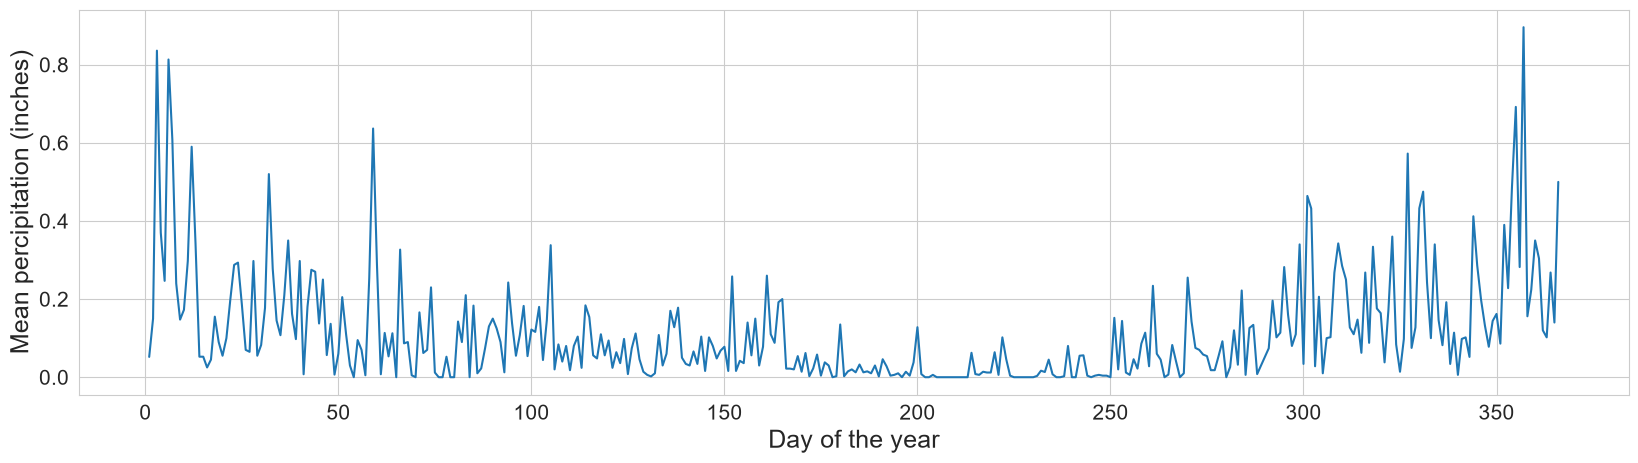

In [41]:
plt.figure(figsize=(20,5))
sns.lineplot(
    data = mean_day_precipitation, 
    x = 'day_of_year',
    y = 'precipitation')
plt.xlabel('Day of the year', fontsize =18)
plt.ylabel('Mean percipitation (inches)', fontsize=18)
plt.tick_params(labelsize=15)
plt.show()
#this particular cell only provides visualization for the mean percipitation of a given day in a year

In [42]:
df['precipitation'].isna() ==True

0       False
1       False
2       False
3       False
4       False
        ...  
3647    False
3648    False
3649    False
3650    False
3651    False
Name: precipitation, Length: 3652, dtype: bool

In [43]:
indices = np.where(df['precipitation'].isna() == True)[0]

In [44]:
print(indices) #only serves to confirm indices created intended array

[1834 1835 1836 1837 1838 1839 1840 1841 1842 1843 1844 1845 1846 1847
 1848 1849 1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861
 1862 1863 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875
 1876 1877 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889
 1890 1891 1892 1893 1894 1895 2090 2131 2132 2133 2134 2135 2136 2137
 2138 2139 2140 2195 2196 2197 2214 2215 2244 2245 2246 2247 2248 2249
 2286 2287 2288 2362 2363 2368 2369 2370 2371 2372 2373 2374 2375 2376
 2377 2417 2418 2419 2420 2421 2422 2423 2517 2518 2519 2520 2521 2522
 2523 2524 2559 2560 2561 2602 2603 2604 2605 2606 2607 2608 2609 2610
 2611 2612 2818 2819 2820 2821 2822 2823 2824 2825 2826 2827 2972 2973
 2974 2975 2983 2984 2986 2987 2988 3000 3001 3004 3005 3006 3007 3008
 3011 3012 3013 3014 3015 3016 3133 3134 3135 3147 3148 3149 3150 3151
 3152 3153 3154 3155 3156 3157 3158 3159 3160 3161 3162 3163 3363 3364
 3365 3366 3367 3368 3369 3370 3371 3372]


In [45]:
for index in indices:
    df.loc[index, 'precipitation']= mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

In [46]:
df.isna().sum() #serves only to confirm there are no more missing values 
#created new column in dataFrame linking the same date in every year to each other.
#The new column to allows and index to be created relating the same dates in every available year and their mean precipitation values. 
#A for loop utilizes this index to iterate over each missing value in precipitation column and replace it with the mean precipitation

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

In [47]:
df.to_csv('clean_Seattle_Detroit_weather.csv', encoding ='utf-8-sig', index = False)
#exports the new Clean dataframe to a .csv file

#Exploratory Data Analysis. Making various graphs and performing various statistical tests to determine if Seattle or Detroit experiences more rain. 

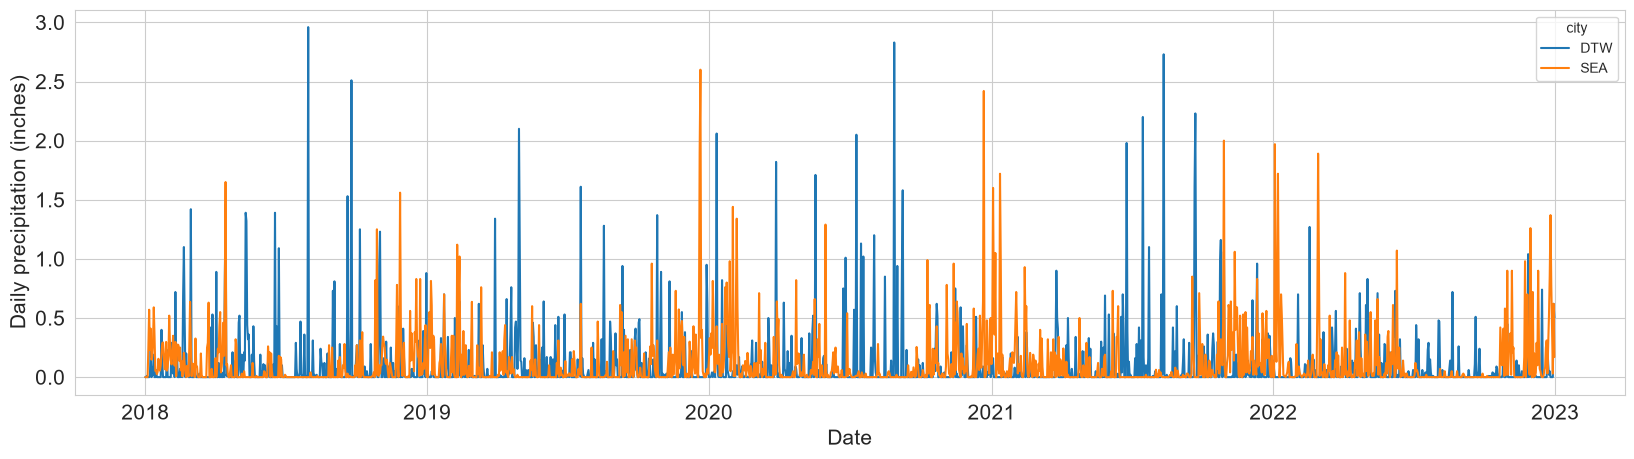

In [86]:
#all precipitation values depicted for every day of the 5 years it was measured 
plt.figure(figsize=(20,5))
sns.lineplot(data=df, x='date', y='precipitation', hue ='city')
plt.xlabel("Date", fontsize=15)
plt.ylabel("Daily precipitation (inches)", fontsize = 15)
plt.tick_params(labelsize=15)
plt.show()
#general impressions is that in 2022 there was lower levels of precipitation in Detroit than in previous years. May want to consider data limitation- if Detroit experienced an uprecedented weather phenomenon in 2022.

In [87]:
df[['city','precipitation']].groupby('city').describe()
#the average precipitation and max precipitation each city experiences overall is similar 

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
DTW         1826.0  0.100345  0.277550  0.0  0.0  0.00  0.05  2.96
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

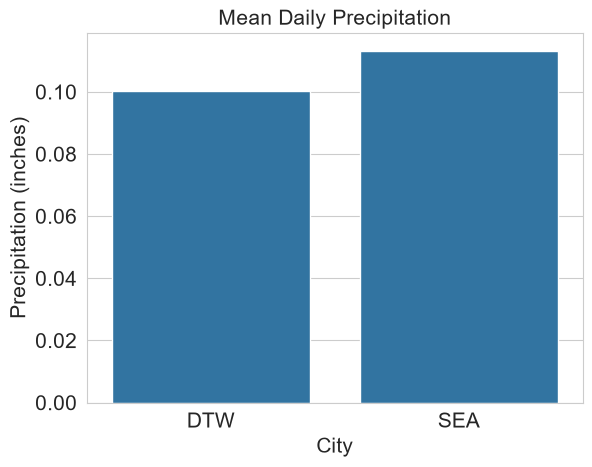

In [50]:
sns.barplot(data=df, x='city', y='precipitation', errorbar=None)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize =15)
plt.title('Mean Daily Precipitation', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

In [51]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [52]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,DTW,0.00,1,1
1,2018-01-02,DTW,0.00,2,1
2,2018-01-03,DTW,0.01,3,1
3,2018-01-04,DTW,0.00,4,1
4,2018-01-05,DTW,0.00,5,1


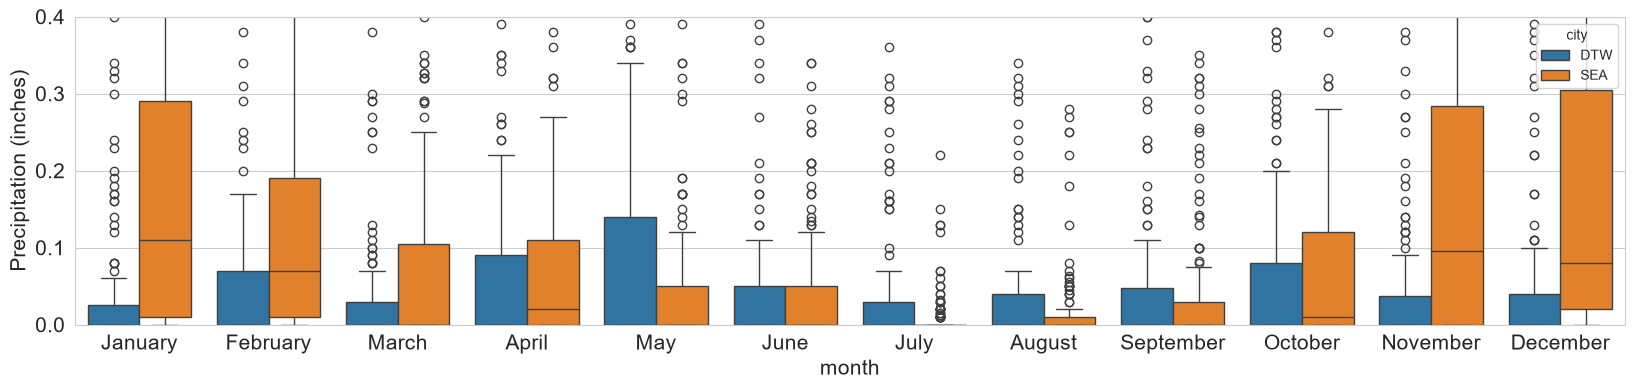

In [88]:
plt.figure(figsize=(20,4))
sns.boxplot(data=df, x='month', y='precipitation', hue='city')
plt.xlabel('month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.tick_params(labelsize=15)
import calendar #retrives month names
month_names= list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)
plt.ylim(0,0.4)
plt.show()
#difficult to see extreeme outliers

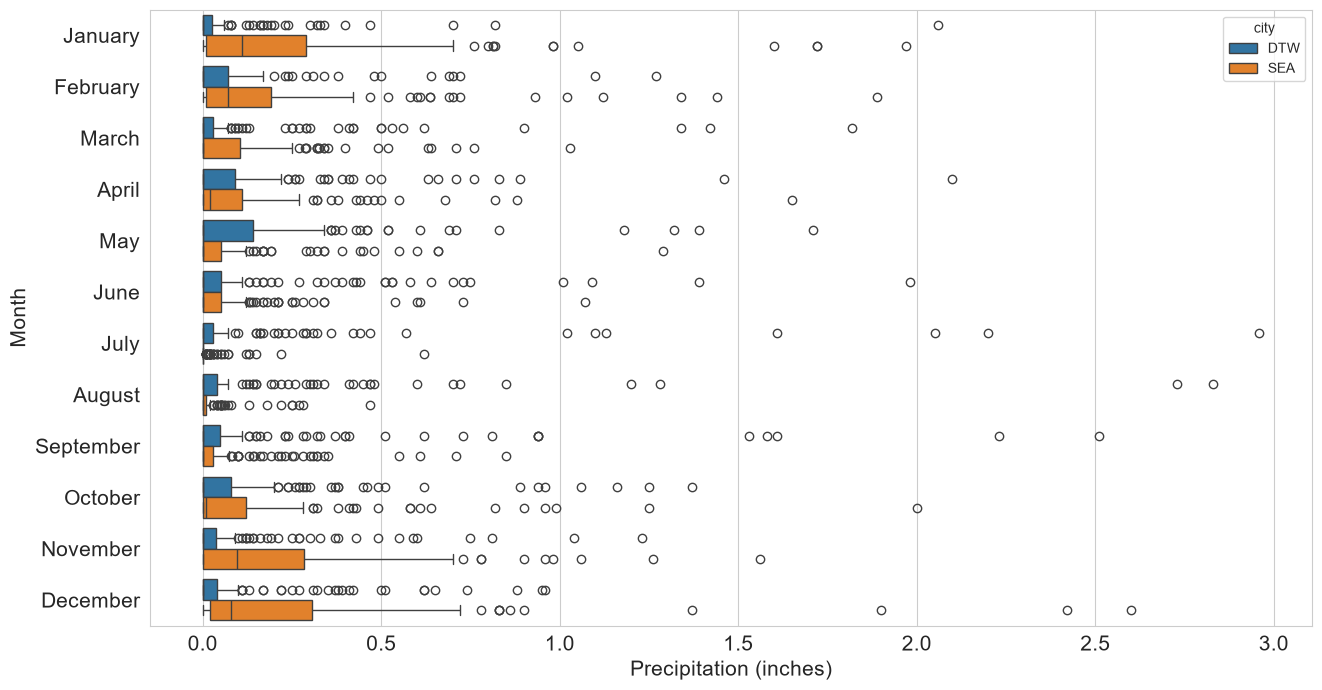

In [89]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x='precipitation', y='month', hue='city', orient='h')
plt.ylabel('Month', fontsize=15)
plt.xlabel('Precipitation (inches)', fontsize=15)
plt.tick_params(labelsize=15)
plt.yticks(ticks=range(12), labels=month_names)
plt.show()
#There is a great number of outliers for both Seattle and Detroit 

In [55]:
df[['month','precipitation', 'city']].groupby(['city','month']).mean()

precipitation
city month               
DTW  1           0.057355
     2           0.083191
     3           0.085548
     4           0.109067
     5           0.126581
     6           0.109533
     7           0.120645
     8           0.114968
     9           0.135133
     10          0.107677
     11          0.075600
     12          0.078194
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

In [56]:
df['any_precipitation'] = df['precipitation'] > 0

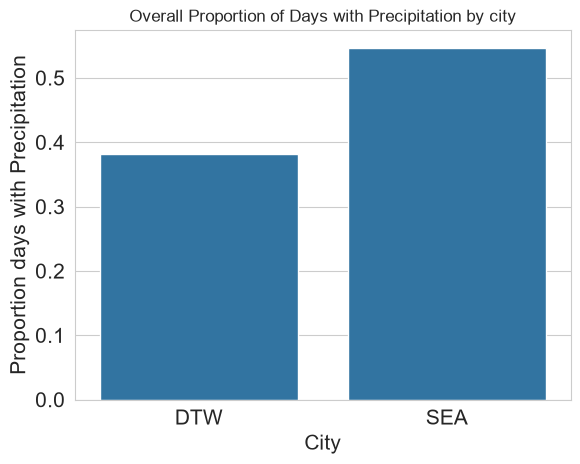

In [90]:
sns.barplot(data = df, x='city', y = 'any_precipitation', errorbar = None)
plt.xlabel('City', fontsize =15)
plt.ylabel('Proportion days with Precipitation', fontsize=15)
plt.title("Overall Proportion of Days with Precipitation by city", fontsize=12)
plt.tick_params(labelsize=15)
plt.show()
#Overall Seattle had a greater number of days with precipiation

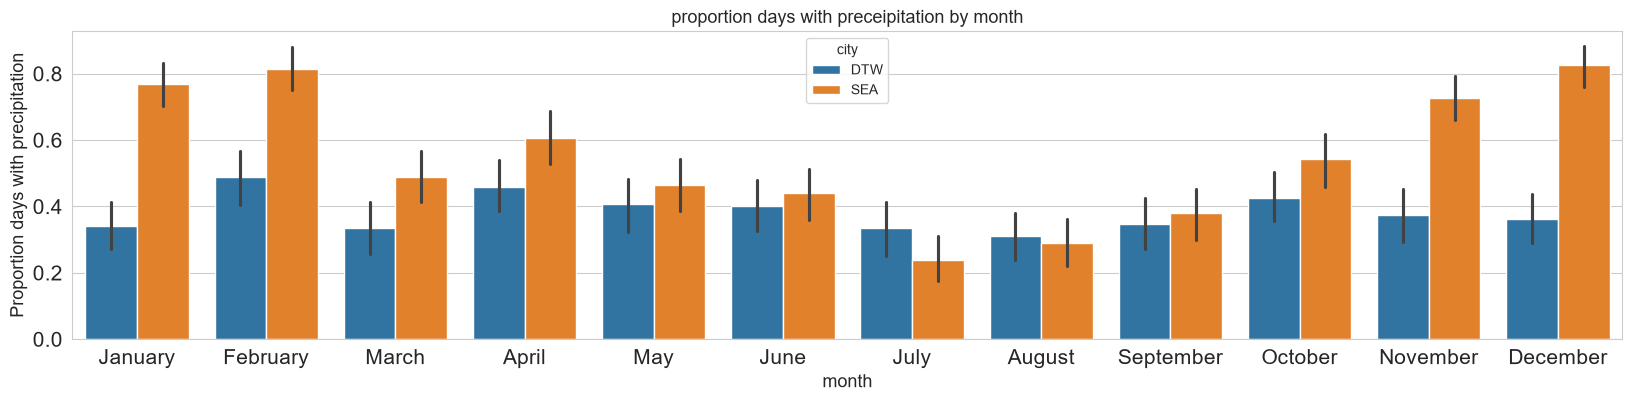

In [91]:
plt.figure(figsize=(20,4))
sns.barplot(data=df, x='month', y='any_precipitation', hue='city')
plt.xlabel('month', fontsize=13)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('proportion days with preceipitation by month', fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)
plt.show()
#first look at number of days with precipitation by month. General impression is that seattle sees more days with precipitation except in summer. 

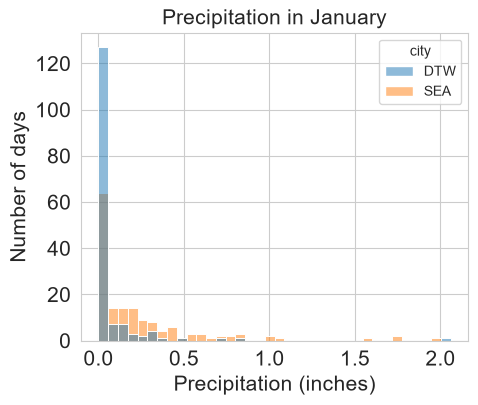

In [76]:
plt.figure(figsize=(5,4))
sns.histplot(data=df.loc[df['month'] == 1], x='precipitation', hue='city')
plt.xlabel('Precipitation (inches)', fontsize=15)
plt.ylabel('Number of days', fontsize=15)
plt.title('Precipitation in January', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()
#double checking the distribution of precipitation values for January over 5 years 

In [80]:
#importing for preforming t-test
from scipy import stats

In [81]:
#t-test for comparing precipitation averages for each month 
significance_level = 0.05
significantly_different=np.zeros(12)

for month in range(1,13):
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month']==month),'precipitation']
    dtw_data = df.loc[(df['city'] == 'DTW') & (df['month']==month),'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, dtw_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1
    print(f"Month {month}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
 t-statistic = 5.45
 p-value t test = 0.000
--------------------
Month 2:
 t-statistic = 3.13
 p-value t test = 0.002
--------------------
Month 3:
 t-statistic = 0.15
 p-value t test = 0.884
--------------------
Month 4:
 t-statistic = -0.32
 p-value t test = 0.751
--------------------
Month 5:
 t-statistic = -2.29
 p-value t test = 0.023
--------------------
Month 6:
 t-statistic = -1.83
 p-value t test = 0.068
--------------------
Month 7:
 t-statistic = -3.36
 p-value t test = 0.001
--------------------
Month 8:
 t-statistic = -3.18
 p-value t test = 0.002
--------------------
Month 9:
 t-statistic = -2.40
 p-value t test = 0.017
--------------------
Month 10:
 t-statistic = 0.37
 p-value t test = 0.709
--------------------
Month 11:
 t-statistic = 4.61
 p-value t test = 0.000
--------------------
Month 12:
 t-statistic = 4.33
 p-value t test = 0.000
--------------------


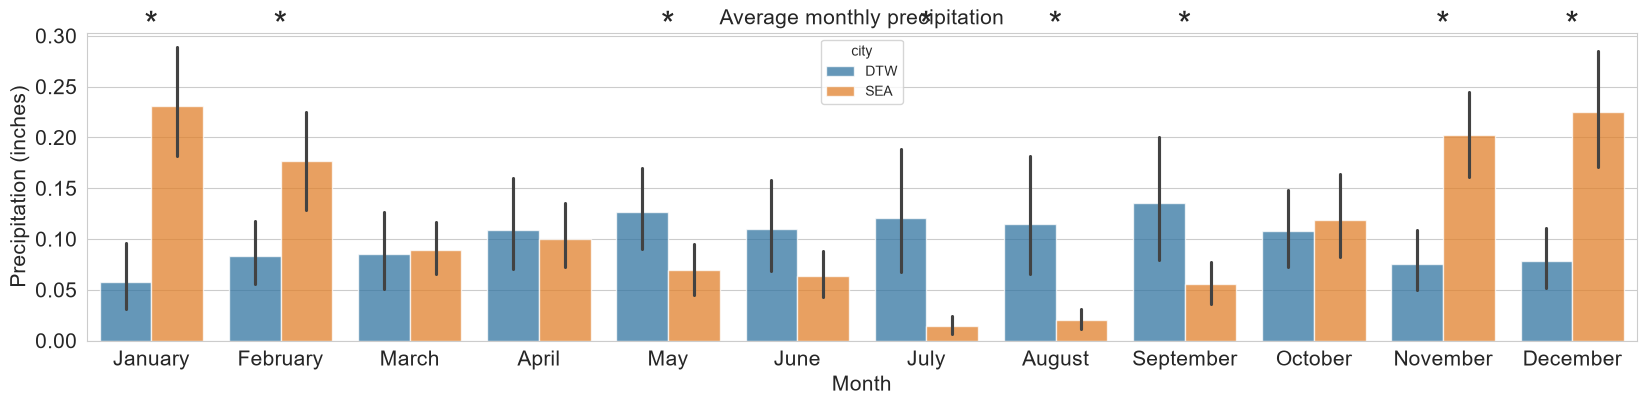

In [82]:
plt.figure(figsize=(20,4))
sns.barplot(data=df, x='month', y='precipitation', hue='city', alpha =0.75)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title("Average monthly precipitation", fontsize=15)

plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)

for month in range(12):
    if significantly_different[month] ==1:
        plt.text(month, 0.3, '*', ha='center', fontsize=25)

plt.show()
#Detroit statistically greater precipitation for May, Jul, Aug, Sept.- late sping, late summer
#Seattle Statistically greater precipitation for Jan, Feb, Nov, Dec - winter

In [84]:
#importing and performing z-tests for days with any precipitation
from statsmodels.stats.proportion import proportions_ztest

significane_level = 0.05
significantly_different_proportion = np.zeros(12)

for month in range(2, 13): 
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'],
        df.loc[df['month'] == month, 'any_precipitation']
    )
    days_with_precipitation = contingency_table[True]
    total_counts = contingency_table.sum(axis=1)
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, 
        nobs=total_counts, 
        alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1]=1

    print(f"month {month}:")
    print(f" z-statistic = {zstat:.2f}")
    print(f" p-value = {p_value:.3f}")
    print("-" * 20)
        
    

month 2:
 z-statistic = -5.75
 p-value = 0.000
--------------------
month 3:
 z-statistic = -2.77
 p-value = 0.006
--------------------
month 4:
 z-statistic = -2.55
 p-value = 0.011
--------------------
month 5:
 z-statistic = -1.03
 p-value = 0.303
--------------------
month 6:
 z-statistic = -0.70
 p-value = 0.483
--------------------
month 7:
 z-statistic = 1.88
 p-value = 0.060
--------------------
month 8:
 z-statistic = 0.37
 p-value = 0.710
--------------------
month 9:
 z-statistic = -0.60
 p-value = 0.548
--------------------
month 10:
 z-statistic = -2.05
 p-value = 0.041
--------------------
month 11:
 z-statistic = -6.15
 p-value = 0.000
--------------------
month 12:
 z-statistic = -8.33
 p-value = 0.000
--------------------


In [92]:
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation']
)
contingency_table
#confirming that contingency_table works as intended

any_precipitation,False,True
city,,
DTW,102,53
SEA,36,119


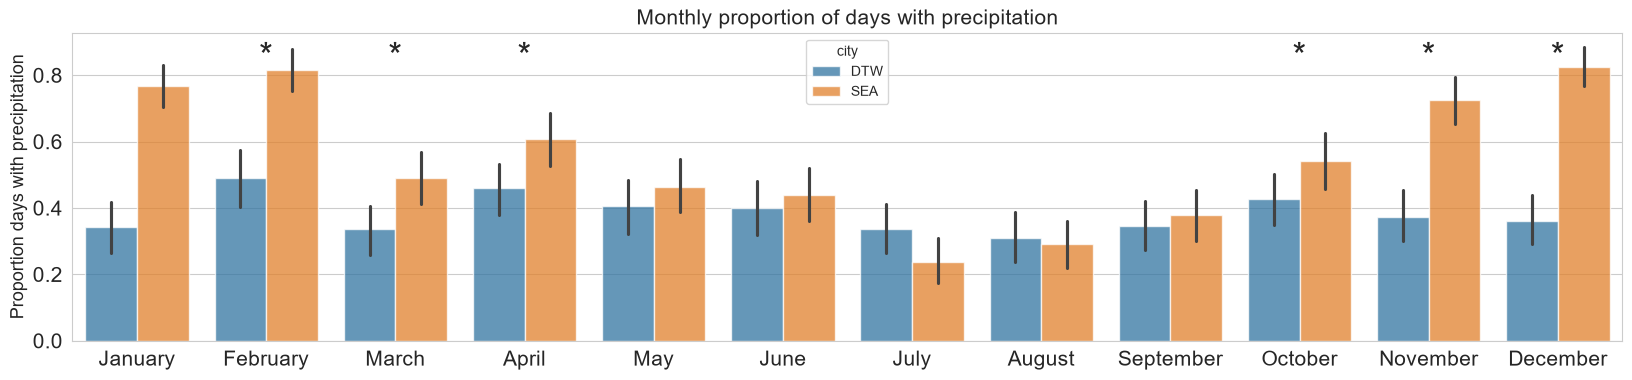

In [93]:
#proportion of days that experienced precipitation per month by city with visualization of z-test results
plt.figure(figsize=(20,4))
sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha =0.75)
plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title("Monthly proportion of days with precipitation", fontsize=15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize=15)

for month in range(12):
    if significantly_different_proportion[month] ==1:
        plt.text(month, 0.825, "*", ha = 'center', fontsize=25)

plt.show()
#Seattle experiences days with precipitation significantly more than Detroit in 6months out of the year while Detroit does not experience a significantly greater number of days with precipitation than Seattle. 